In [1]:
import re
import matplotlib.pyplot as plt
import os
import matplotlib.cm as cm
import numpy as np
#now hop to the end of the cell to init the functions for plotting (didn't put them at the beginning to avoid clutter)

To cut down on data collection overhead and the number of files of report per experiment, I'm going to start trying to integrate together the usual google doc reports and training visualizations by putting the stuff from the google doc into the markdown section of jupyter notebooks and using the code cells for viz. Feedback appreciated. 

# Version Information

- **Git Commit ID:** `2481977822a6140f4965e9894164d3abb09c0c8e`
- **Hydra Model Path:** Original CDVAE control
- **New Model (On Perov):** 
  - A bunch of models were tried, the model checkpoints are all in the 2023-11-11 and 2023-11-12 folders with names that should (I hope) be very clear as to what their purpose is. If not, the hparams.yaml file in each model folder should make it clear as it contains all of the initial conditions and those were the only things that were changed between the models. 
  - **Training Logs:** specified in the code cells below  
  - **Eval Log:** NA (none of the training runs went well enough that I felt it made sense to evaluate them 
- **New Model (On Materials Project):** 
  - A bunch of models were tried, the model checkpoints are all in the 2023-11-11 and 2023-11-12 folders with names that should (I hope) be very clear as to what their purpose is. If not, the hparams.yaml file in each model folder should make it clear as it contains all of the initial conditions and those were the only things that were changed between the models. 
  - **Training Log:** specified in the code cells below  
  - **Eval Log:** `NA (none of the training runs went well enough that I felt it made sense to evaluate them 
- **Development Notebook:** NA (was a 1 line addition to the code)

# Architecture Notes

- **Architecture:** Same as 11-07 type_fixing model except now has x% random dropout, either placed inside of the encoder (default) or right before the decoder ("decoder dropout")

# Motivation

- **Goal:** Reduce overfitting on the coordinates, as has been obsrved in previous models. 

# Analysis of Results

- **Findings:** Implementation of a dropout at the input layer (either in the default or "decoder dropout setting"), while it does seem to address the coordinate overfitting, comes at the cost of the lattice predictions, which were already the greatest "weakness" of the diffraction pattern models to begin with. Additionally, while the characteristics of the coordinate loss appear to be different during training, coordinate prediction performance on the validation set in aggregate seems ok and definitely better than the lattice paramters predictions (see "training comparisons"). Main conclusions are to take a break from the regularization efforts for now and maybe focus more on the lattice parameters prediction problem. Also, when you come back to regularization, try noise-based or multi-layer dropout. 

## Results

### Perov

- **Training:**

In [5]:
file_paths = {"no dropout": "/home/gridsan/tmackey/cdvae/output/no_encode_intensity_concat_comp_concat_neg_mask_type_fixing_24213840_output.txt",
             "20 dropout type w fixing":  "/home/gridsan/tmackey/cdvae/output/dropout_input_layer_20_perov_24254983_output.txt",
              "20 decoder dropout": "/home/gridsan/tmackey/cdvae/output/20_decoder_dropout_perov_24257249_output.txt",
             "original w comp constraint": "/home/gridsan/tmackey/cdvae/output/og_CDVAE_dropout_input_layer_24249924_output.txt"}
myepoch_dict =  epoch_dict_getter(file_paths)

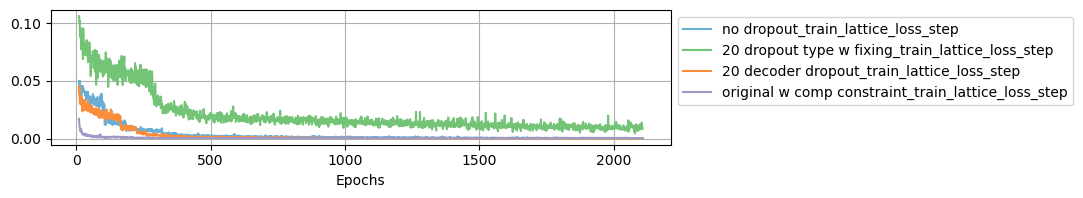

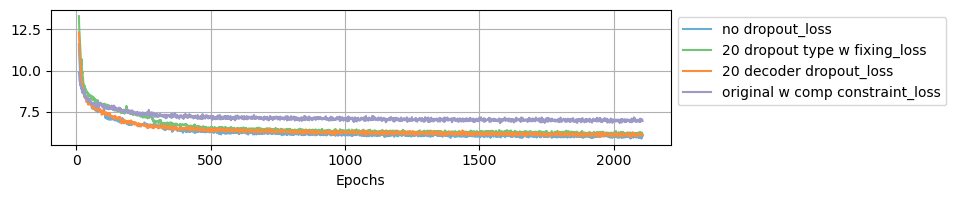

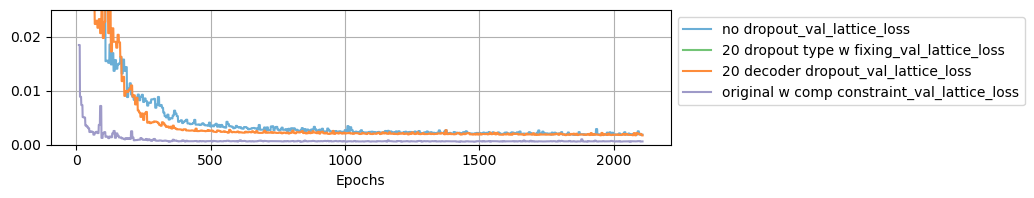

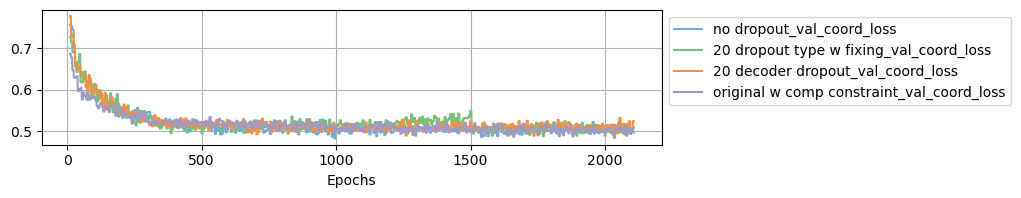

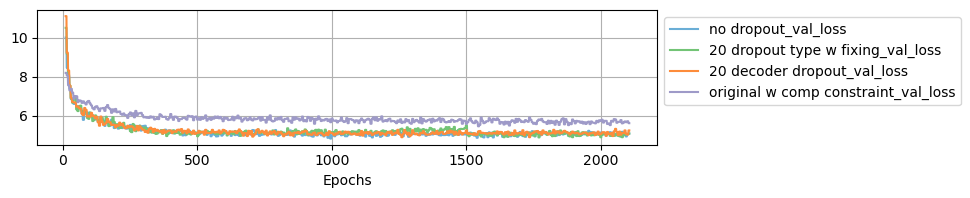

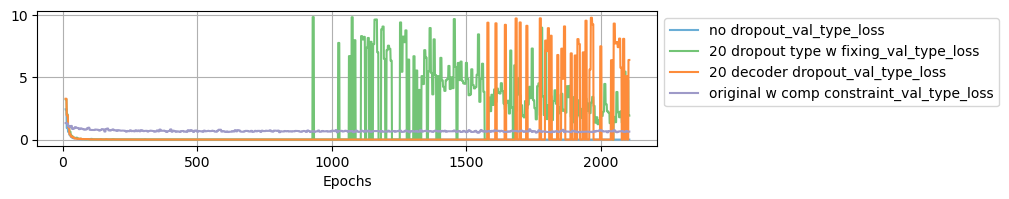

In [8]:
max_length = len(myepoch_dict[ "20 decoder dropout"])
neo_plotter(myepoch_dict, ['train_lattice_loss_step'], domain = [10, max_length])
neo_plotter(myepoch_dict, ['loss'], domain = [10, max_length])
neo_plotter(myepoch_dict, ['val_lattice_loss'], domain = [10, max_length], y_lim = 0.025)
neo_plotter(myepoch_dict, ['val_coord_loss'], domain = [10, max_length])
neo_plotter(myepoch_dict, ['val_loss'], domain = [10, max_length])
neo_plotter(myepoch_dict, ['val_type_loss'], domain = [10, max_length])


- **Testing:**
  - None of the dropout models seemed to outperform the non-dropout models on the relevant training losses, so evaluation was not performed



### Materials Project

- **Training:**

In [6]:
file_paths = {"no dropout w type fixing": "/home/gridsan/tmackey/cdvae/output/no_encode_intensity_concat_comp_concat_neg_mask_type_fixing_mp_20_24213842_output.txt",
             "drouput w type fixing" : "/home/gridsan/tmackey/cdvae/output/dropout_input_layer_v3_mp_20_24235715_output.txt", 
             "20 percent decoder dropout w type fixing" : "/home/gridsan/tmackey/cdvae/output/20_dropout_decoder_mp_20_24258678_output.txt",
              "original w comp constraint": "/home/gridsan/tmackey/cdvae/output/og_CDVAE_neg_mask_mp_20_24141459_output.txt"}
myepoch_dict =  epoch_dict_getter(file_paths)

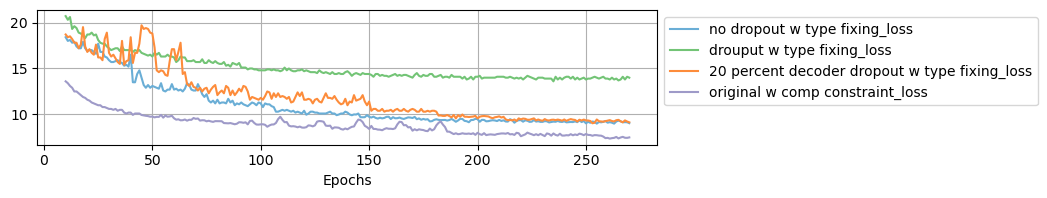

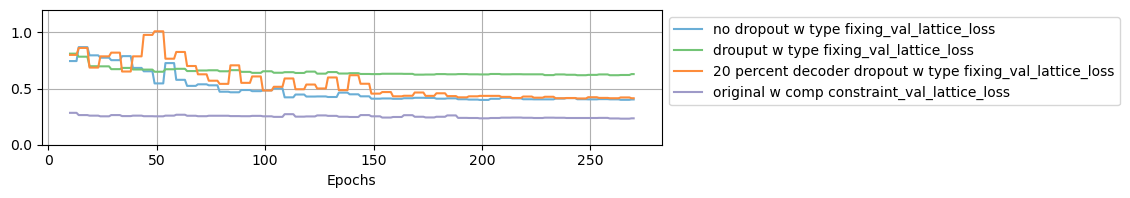

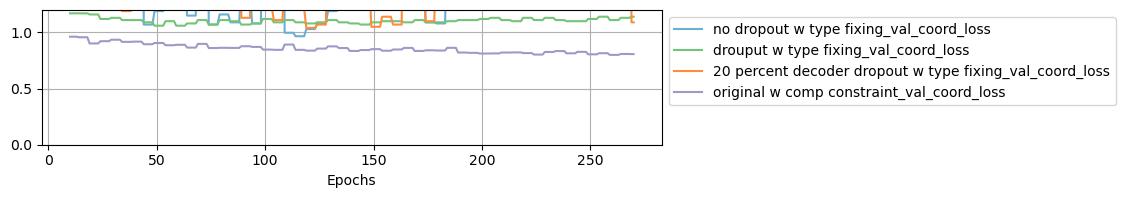

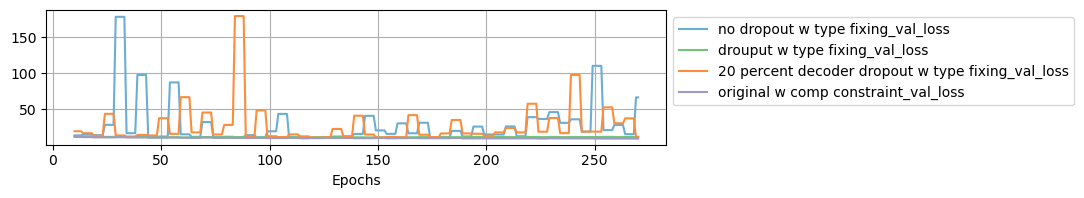

In [9]:
max_length = len(myepoch_dict["20 percent decoder dropout w type fixing"])
neo_plotter(myepoch_dict, ['loss'], domain = [10, max_length])
neo_plotter(myepoch_dict, ['val_lattice_loss'], domain = [10, max_length], y_lim = 1.2)
neo_plotter(myepoch_dict, ['val_coord_loss'], domain = [10, max_length], y_lim = 1.2)
neo_plotter(myepoch_dict, ['val_loss'], domain = [10, max_length])

- **Testing:**
  - None of the dropout models seemed to outperform the non-dropout models on the relevant training losses, so evaluation was not performed


Some functions for plotting

In [2]:
def extract_epoch_data(file_path):
    # Pattern to match the metrics in the line
    pattern = r"(?P<name>\w+)=?(?P<value>[\d.]+)"

    # Dictionary to store all metrics
    all_data = {}

    with open(file_path, 'r') as file:
        for line in file:
            # Extract epoch number
            epoch_match = re.search(r"Epoch (\d+):", line)
            if epoch_match:
                epoch_num = int(epoch_match.group(1))
                metrics = re.findall(pattern, line)
                
                # Add the data to the dictionary
                epoch_data = {}
                for name, value in metrics:
                    try: 
                        epoch_data[name] = float(value)
                    except: 
                        continue
                
                all_data[epoch_num] = epoch_data

    return all_data

def neo_plotter(epoch_dict, components_to_extract, domain = [10, 1000], y_lim = None, colorlist = ['Blues',
          'Greens', 
          'Oranges', 
          'Purples', 
          'Reds'], size = (8,1.75)): 
    plt.figure(figsize=size)
    plotting_data = {}
    counter = 0 
    for my_label, epoch_data in epoch_dict.items(): 
        
        epochs = list(epoch_data.keys())
        # Generate a color palette
        cmap = plt.colormaps[colorlist[counter]]
        
        start = 0.5  # Adjust start and end to get the desired shade range
        end = 1.0
        colors = [cmap(x) for x in np.linspace(start, end, len(components_to_extract))]

        for i, component in enumerate(components_to_extract): 
            plotting_data[component] = [per_epoch_data[component] for epoch_number, per_epoch_data  in epoch_data.items()]
            component_label = str(my_label) + "_" + str(component)
            plt.plot(list(range(domain[0], domain[1])), plotting_data[component][domain[0]:domain[1]], 
                     label=component_label, color = colors[i])
        counter += 1
        
    plt.xlabel("Epochs")
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True)
    if y_lim is not None: 
        plt.ylim(0, y_lim)
    plt.show()

def epoch_dict_getter(file_paths): 
    epoch_dict = {}
    for my_label, file_path in file_paths.items():
        epoch_data = extract_epoch_data(file_path)
        epoch_dict[my_label] = epoch_data
        
    return(epoch_dict)

In [3]:
##### example data for reference
# Example of data: 

# {0: {'10': 6.0,
#   '0': 0.0,
#   'loss': 44.9,
#   'ym': 8.0,
#   'val_loss': 1.11,
#   'val_natom_loss': 16.5,
#   'val_lattice_loss': 75.0,
#   'val_coord_loss': 1.11,
#   'val_type_loss': 2.29,
#   'val_kld_loss': 0.0,
#   'val_composition_loss': 5.72,
#   'val_diffraction_loss': 0.0,
#   'val_property_loss': 0.0,
#   'val_natom_accuracy': 0.0391,
#   'val_lengths_mard': 2.45,
#   'val_angles_mae': 96.2,
#   'val_volumes_mard': 3.44,
#   'val_type_accuracy': 0.338,
#   'train_loss_step': 44.0,
#   'train_natom_loss_step': 2.08,
#   'train_lattice_loss_step': 1.23,
#   'train_coord_loss_step': 1.17,
#   'train_type_loss_step': 16.8,
#   'train_kld_loss_step': 0.0,
#   'train_composition_loss_step': 1.07,
#   'train_diffraction_loss_step': 0.0},